In [1]:
import slangpy as spy
from pyglm import glm
import torch
import torchvision
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt

from cs248a_renderer import setup_device, RendererModules
from cs248a_renderer.model.cameras import PerspectiveCamera
from cs248a_renderer.renderer.core_renderer import Renderer
from cs248a_renderer.model.volumes import DenseVolume
from cs248a_renderer.model.transforms import Transform3D

from cs231nfinal.camera import RandomCameraTransform

%load_ext autoreload
%autoreload 2

device = setup_device([])
renderer_modules = RendererModules(device)

[WARN] No supported shader model found, pretending to support sm_6_0.


In [2]:
# OUTPUT_IMG_SIZE = (800, 800)
OUTPUT_IMG_SIZE = (500, 500)

# create framebuffers
output_image = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.r32_float,
    usage=spy.TextureUsage.unordered_access,
    width=OUTPUT_IMG_SIZE[0],
    height=OUTPUT_IMG_SIZE[1],
)

output_mask = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.r32_float,
    usage=spy.TextureUsage.unordered_access,
    width=OUTPUT_IMG_SIZE[0],
    height=OUTPUT_IMG_SIZE[1],
)

output_view = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.r32_float,
    usage=spy.TextureUsage.unordered_access,
    width=OUTPUT_IMG_SIZE[0],
    height=OUTPUT_IMG_SIZE[1],
)

# Setup the renderer
renderer = Renderer(
    device=device,
    render_texture=output_image,
    render_modules=renderer_modules
)
renderer.sqrt_spp = 1
renderer._ambientColor = glm.vec4(1.0, 1.0, 1.0, 1.0)

mask_renderer = Renderer(
    device=device,
    render_texture=output_mask,
    render_modules=renderer_modules
)
mask_renderer.sqrt_spp = 1
mask_renderer._ambientColor = glm.vec4(1.0, 1.0, 1.0, 1.0)

preview_renderer = Renderer(
    device=device,
    render_texture=output_view,
    render_modules=renderer_modules
)
preview_renderer.sqrt_spp = 1
preview_renderer._ambientColor = glm.vec4(1.0, 1.0, 1.0, 1.0)

In [3]:
from cs231nfinal.data import DatasetID, DataSet
import numpy as np
from openvdb import FloatGrid

dataset = DataSet.Get(DatasetID.SMOKE_LOWRES)

data_array = np.zeros(dataset.resolution)
grid = dataset.get_grid("density", frame=70, type=FloatGrid)

grid.copyToArray(data_array, ijk=grid.evalLeafBoundingBox()[0])
min, max = grid.evalMinMax()

# normalize data
data_array = 0.5 * ((data_array + min) / (max - min))

In [26]:
# cam_transform = RandomCameraTransform(glm.vec3(25,0,0), sigma=0.8)
cam_transform = RandomCameraTransform(glm.vec3(25,0,0), sigma=0.5)
fov = 40

canonical_cam = next(RandomCameraTransform(glm.vec3(25,0,0), sigma=0))

In [27]:

_resize_transform = torchvision.transforms.Resize(OUTPUT_IMG_SIZE)
_grayscale_transform = torchvision.transforms.Grayscale()
prep_style = lambda t: _grayscale_transform(_resize_transform(t)).squeeze()

# style_img = torch.stack([
#     *resize_transform(torchvision.io.read_image("data/style/good_ones/dark_matter_bw.png") / 255),
#     torch.ones(OUTPUT_IMG_SIZE),
# ]).permute(1,2,0)
style_img = 1 - prep_style(torchvision.io.read_image("data/style/good_ones/dark_matter_bw.png") / 255)

(100, 100, 100)


Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

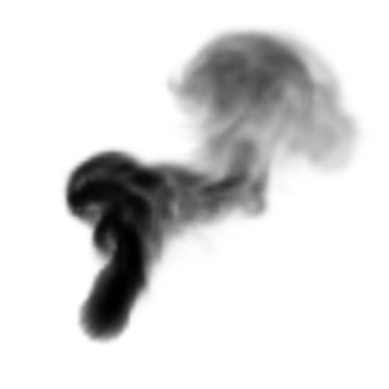

Views:   0%|          | 0/8 [00:00<?, ?it/s]

Views:   0%|          | 0/8 [00:00<?, ?it/s]

Views:   0%|          | 0/8 [00:00<?, ?it/s]

Views:   0%|          | 0/8 [00:00<?, ?it/s]

Views:   0%|          | 0/8 [00:00<?, ?it/s]

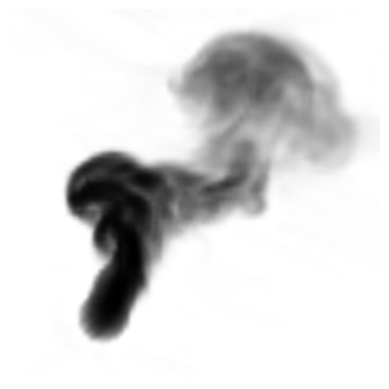

Views:   0%|          | 0/8 [00:00<?, ?it/s]

Views:   0%|          | 0/8 [00:00<?, ?it/s]

Views:   0%|          | 0/8 [00:00<?, ?it/s]

Views:   0%|          | 0/8 [00:00<?, ?it/s]

Views:   0%|          | 0/8 [00:00<?, ?it/s]

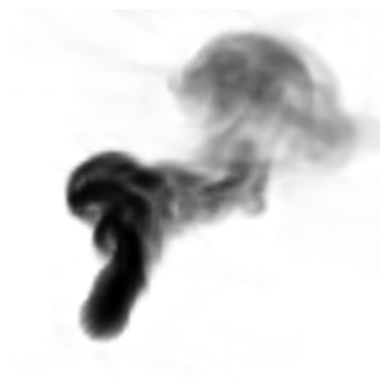

Views:   0%|          | 0/8 [00:00<?, ?it/s]

Views:   0%|          | 0/8 [00:00<?, ?it/s]

Views:   0%|          | 0/8 [00:00<?, ?it/s]

Views:   0%|          | 0/8 [00:00<?, ?it/s]

Views:   0%|          | 0/8 [00:00<?, ?it/s]

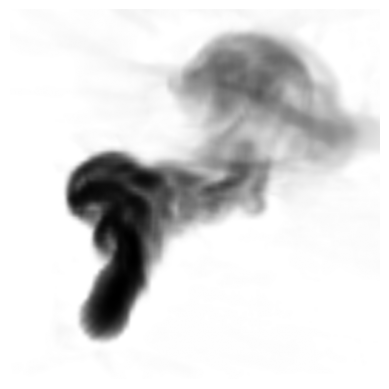

Views:   0%|          | 0/8 [00:00<?, ?it/s]

Views:   0%|          | 0/8 [00:00<?, ?it/s]

Views:   0%|          | 0/8 [00:00<?, ?it/s]

Views:   0%|          | 0/8 [00:00<?, ?it/s]

Views:   0%|          | 0/8 [00:00<?, ?it/s]

In [34]:
num_epochs = 20
num_views = 8

volume_tensor = torch.tensor(data_array.astype(np.float32), requires_grad=True)

optim = torch.optim.Adam([volume_tensor], lr=5e-4)
# scheduler = torch.optim.lr_scheduler.ExponentialLR(optim, 0.99)


mask_dense_volume = DenseVolume(
    name="volume",
    transform=Transform3D(position=glm.vec3(0,3,4)),
    data=volume_tensor.detach().numpy().astype(np.float32),
    properties={
        "pivot": (0.5, 0.5, 0.5),
        "voxel_size": dataset.voxel_size,
    },
)
print(mask_dense_volume.data.shape)
mask_renderer.load_volume(mask_dense_volume)

batch_losses = []

for epoch in tqdm(range(num_epochs), desc="Epochs"):
    optim.zero_grad()

    dense_volume = DenseVolume(
        name="volume",
        transform=Transform3D(position=glm.vec3(0,3,4)),
        data=volume_tensor.detach().numpy().astype(np.float32),
        properties={
            "pivot": (0.5, 0.5, 0.5),
            "voxel_size": dataset.voxel_size,
        },
    )

    renderer.load_volume(volume=dense_volume)

    if (epoch % 5) == 0:
        preview_renderer.load_volume(volume=dense_volume)
        preview_renderer.render(canonical_cam, fov)
        preview_res = np.flipud(output_view.to_numpy().copy())
        plt.imshow(preview_res, cmap="gray")
        plt.axis("off")
        plt.show()
    
    grad_acc = np.zeros(volume_tensor.shape).astype(np.float32)
    for i in tqdm(range(num_views), desc="Views"):
        batch_loss = 0

        view_mat = next(cam_transform)

        renderer.render(view_mat, fov)
        mask_renderer.render(view_mat, fov)

        img_res = torch.tensor(np.flipud(output_image.to_numpy()).copy(), requires_grad=True)
        
        mask_res = 1 - torch.tensor(np.flipud(output_mask.to_numpy()).copy(), requires_grad=False)
        min_alpha = 0.2
        mask_res = torch.maximum(mask_res - min_alpha, torch.tensor(0.0)) / (1 - min_alpha)
        mask_res *= 1 - mask_res

        # mask = (mask_res[:,:,:3] < 1.0)
        # mask = mask_res[:,:,:3]
        # mask = mask_res < 1.0
        # masked_style = style_img.detach().clone()
        # masked_style *= mask
        # masked_style += (1 - mask.type(torch.float32))
        # masked_style = (1 - mask_res) * style_img.detach().clone() + mask_res

        masked_style = style_img.detach().clone()


        # plt.imshow(img_res.detach().numpy(), cmap="gray")
        # plt.xlabel(f"Current vol; epoch: {epoch}, view: {i}")
        # plt.show()
        # plt.imshow(masked_style.detach().numpy(), cmap="gray")
        # plt.xlabel(f"Masked Style; epoch: {epoch}, view: {i}")
        # plt.show()
        
        # loss_fn = torch.nn.MSELoss()
        # loss = loss_fn(masked_style, img_res)
        loss = torch.sum(
            mask_res * 
            (masked_style - img_res) ** 2
        )
        batch_loss += loss.item()

        loss.backward()
        grad_res = img_res.grad

        # plt.imshow(grad_res.detach().numpy())
        # plt.xlabel(f"Image Gradient; epoch: {epoch}, view: {i}")
        # plt.colorbar()
        # plt.show()

        renderer.render_volume_backward(view_mat=view_mat, fov=fov, out_grad=torch.flipud(grad_res))
        d_volume = renderer.get_d_volume().reshape(volume_tensor.shape)
        grad_acc += d_volume

    with torch.no_grad():
        volume_tensor.grad = torch.tensor(grad_acc)
    optim.step()
    # scheduler.step()



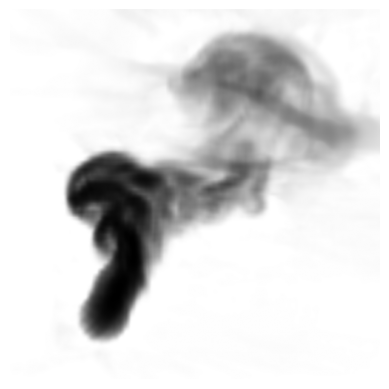

In [35]:
renderer.render(canonical_cam, fov)

img_res = torch.tensor(np.flipud(output_image.to_numpy()).copy(), requires_grad=True)
plt.imshow(img_res.detach().numpy(), cmap="gray")
plt.axis("off")
plt.show()